# OrigamiPipeline Tutorial: Training on Real Data

This notebook provides a step-by-step guide to using the `OrigamiPipeline` API for training, saving, and using ORIGAMI models on real-world data.

**What you'll learn:**
1. Loading and exploring JSON data
2. Training with default and custom configurations
3. Saving and loading trained pipelines
4. Making predictions on new data
5. Generating synthetic samples
6. Extracting embeddings for downstream tasks

**Dataset:** We'll use the UCI Car Evaluation dataset, which contains nested JSON objects describing car attributes and their acceptability ratings.

## 1. Setup and Imports

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import torch

from origami import OrigamiPipeline, PipelineConfig

# For reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1


## 2. Load and Explore the Data

The car dataset contains nested JSON objects with car attributes and acceptability ratings.

In [2]:
# Load data from JSONL file
data_path = Path("../datasets/car.jsonl")

with open(data_path) as f:
    raw_data = [json.loads(line) for line in f]

print(f"Loaded {len(raw_data)} records")
print(f"\nSample record:")
print(json.dumps(raw_data[0], indent=2))

Loaded 1728 records

Sample record:
{
  "_id": {
    "$oid": "66c32b7fac3485a3c76f7e74"
  },
  "PRICE": {
    "buying": "vhigh",
    "maint": "vhigh"
  },
  "TECH": {
    "COMFORT": {
      "doors": 2,
      "persons": 2,
      "lug_boot": "small"
    },
    "safety": "low"
  },
  "target": "unacc"
}


In [3]:
# Remove MongoDB _id field (not useful for modeling)
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in raw_data]

print("Cleaned record:")
print(json.dumps(data[0], indent=2))

Cleaned record:
{
  "PRICE": {
    "buying": "vhigh",
    "maint": "vhigh"
  },
  "TECH": {
    "COMFORT": {
      "doors": 2,
      "persons": 2,
      "lug_boot": "small"
    },
    "safety": "low"
  },
  "target": "unacc"
}


In [4]:
# Explore the data structure
print("Data structure:")
print("- PRICE: buying price and maintenance cost")
print("- TECH: technical specs (comfort features + safety)")
print("- target: acceptability rating\n")

# Count target values
target_counts = Counter(d["target"] for d in data)
print("Target distribution:")
for target, count in sorted(target_counts.items()):
    print(f"  {target}: {count} ({count / len(data) * 100:.1f}%)")

Data structure:
- PRICE: buying price and maintenance cost
- TECH: technical specs (comfort features + safety)
- target: acceptability rating

Target distribution:
  acc: 384 (22.2%)
  good: 69 (4.0%)
  unacc: 1210 (70.0%)
  vgood: 65 (3.8%)


In [5]:
# Split into train/eval sets
random.shuffle(data)
split_idx = int(0.8 * len(data))
train_data = data[:split_idx]
eval_data = data[split_idx:]

print(f"Train set: {len(train_data)} records")
print(f"Eval set: {len(eval_data)} records")

Train set: 1382 records
Eval set: 346 records


## 3. Training with Default Configuration

The simplest way to use `OrigamiPipeline` is with default settings. Just create a pipeline and call `fit()`.

In [6]:
# Create pipeline with default config
pipeline = OrigamiPipeline()

# View default configuration
print("Default configuration:")
print(pipeline)

Default configuration:
OrigamiPipeline(numeric_mode='none', not fitted)


In [7]:
# Train with defaults (quick training for demonstration)
pipeline.fit(train_data, eval_data=eval_data, epochs=100)

print(f"\nTraining complete!")
print(f"Model parameters: {pipeline._model.get_num_parameters():,}")

Training on mps
Train samples: 1382 (base: 1382, upscale: 1x)
Eval samples: 346
Batch size: 32
Epochs: 100
Total steps: 4300



Epoch 1:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 1/100 - loss: 2.4850 - tokens/sec: 23137
Eval: val_loss: 2.0606


Epoch 2:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 2/100 - loss: 1.8126 - tokens/sec: 29873
Eval: val_loss: 1.3520


...

Epoch 10:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 10/100 - loss: 0.5370 - tokens/sec: 28899
Eval: val_loss: 0.5115


Epoch 11:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 11/100 - loss: 0.5331 - tokens/sec: 27795


KeyboardInterrupt: 

## 4. Training with Custom Configuration

`PipelineConfig` lets you customize model architecture, training parameters, and preprocessing options.

In [8]:
from origami.training import accuracy

# Create a custom configuration
custom_config = PipelineConfig(
    # Model architecture
    d_model=128,  # Embedding dimension
    n_heads=4,  # Attention heads (must divide d_model)
    n_layers=4,  # Transformer layers
    d_ff=512,  # Feed-forward dimension
    dropout=0.1,  # Dropout rate
    # Position encoding
    kvpe_pooling="sum",  # How to combine path elements: "sum", "weighted", "gru"
    # Training parameters
    batch_size=32,
    learning_rate=1e-3,
    warmup_steps=100,
    shuffle_keys=True,  # Data augmentation via key order shuffling
    upscale_factor=2,  # Each sample seen 2x with different key orders
    # Numeric handling ("none", "discretize", or "scale")
    numeric_mode="none",  # Car dataset has no high-cardinality numerics
    # Evaluation
    eval_strategy="steps",
    eval_steps=100,
    eval_metrics={"acc": accuracy},
    target_key="target",
    eval_sample_size=25,
    eval_on_train=True,  # Evaluate on training data as well
)

print("Custom configuration:")
print(f"  d_model: {custom_config.d_model}")
print(f"  n_layers: {custom_config.n_layers}")
print(f"  batch_size: {custom_config.batch_size}")
print(f"  upscale_factor: {custom_config.upscale_factor}")

Custom configuration:
  d_model: 128
  n_layers: 4
  batch_size: 32
  upscale_factor: 2


In [9]:
from origami.training import TableLogCallback

# Create and train pipeline with custom config
pipeline = OrigamiPipeline(custom_config)
pipeline.fit(
    train_data, eval_data=eval_data, callbacks=[TableLogCallback(print_every=100)], epochs=50
)

print(f"\nTraining complete!")
print(f"Model parameters: {pipeline._model.get_num_parameters():,}")

| step: 100 | epoch: 1 | lr: 9.77e-04 | batch_dt: 17ms | loss: 0.5712 | train_acc: 0.6800 | train_loss: 0.5191 | val_acc: 0.7600 | val_loss: 0.5321 |
| step: 200 | epoch: 2 | lr: 9.53e-04 | batch_dt: 20ms | loss: 0.5297 | train_acc: 0.6000 | train_loss: 0.5101 | val_acc: 0.7200 | val_loss: 0.4986 |
| step: 300 | epoch: 3 | lr: 9.30e-04 | batch_dt: 16ms | loss: 0.5369 | train_acc: 0.7200 | train_loss: 0.5107 | val_acc: 0.8000 | val_loss: 0.5049 |
| step: 400 | epoch: 4 | lr: 9.07e-04 | batch_dt: 17ms | loss: 0.5198 | train_acc: 0.9200 | train_loss: 0.5043 | val_acc: 0.6400 | val_loss: 0.5273 |
| step: 500 | epoch: 5 | lr: 8.84e-04 | batch_dt: 20ms | loss: 0.5092 | train_acc: 0.8000 | train_loss: 0.4967 | val_acc: 0.8400 | val_loss: 0.4965 |
| step: 600 | epoch: 6 | lr: 8.60e-04 | batch_dt: 18ms | loss: 0.5023 | train_acc: 0.9200 | train_loss: 0.4941 | val_acc: 0.8400 | val_loss: 0.4950 |
| step: 700 | epoch: 8 | lr: 8.37e-04 | batch_dt: 17ms | loss: 0.5048 | train_acc: 0.9200 | train_lo

## 5. Saving and Loading Pipelines

Trained pipelines can be saved to disk and loaded later. The checkpoint includes the model weights, tokenizer vocabulary, configuration, and any preprocessors.

In [ ]:
# Save the trained pipeline
save_path = Path("car_pipeline.pt")
pipeline.save(save_path)

print(f"Pipeline saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

In [ ]:
# Load the pipeline (demonstrates how to use a saved model)
save_path = Path("car_pipeline.pt")
pipeline = OrigamiPipeline.load(save_path)

print("Loaded pipeline:")
print(pipeline)

# Clean up
# save_path.unlink()
# print(f"\nCleaned up {save_path}")

## 6. Making Predictions

Use `predict()` to predict a missing field value given the rest of the object. This is useful for classification, imputation, and recommendation tasks.

In [10]:
# Create a test object with missing target
test_obj = {
    "PRICE": {"buying": "low", "maint": "low"},
    "TECH": {"COMFORT": {"doors": 4, "persons": 4, "lug_boot": "big"}, "safety": "high"},
    "target": None,  # We want to predict this
}

print("Test object (target unknown):")
print(json.dumps(test_obj, indent=2))

Test object (target unknown):
{
  "PRICE": {
    "buying": "low",
    "maint": "low"
  },
  "TECH": {
    "COMFORT": {
      "doors": 4,
      "persons": 4,
      "lug_boot": "big"
    },
    "safety": "high"
  },
  "target": null
}


In [11]:
# Predict the target field
prediction = pipeline.predict(test_obj, target_key="target")
print(f"Predicted target: {prediction}")

# Get top-k predictions with probabilities using predict_proba
top_predictions = pipeline.predict_proba(test_obj, target_key="target", top_k=4)
print("\nTop predictions with probabilities:")
for value, prob in top_predictions:
    print(f"  {value}: {prob:.1%}")

Predicted target: vgood

Top predictions with probabilities:
  vgood: 98.4%
  good: 1.3%
  acc: 0.1%
  unacc: 0.0%


In [12]:
# Try different car configurations
test_cases = [
    # Expensive, unsafe car
    {
        "PRICE": {"buying": "vhigh", "maint": "vhigh"},
        "TECH": {"COMFORT": {"doors": 2, "persons": 2, "lug_boot": "small"}, "safety": "low"},
        "target": None,
    },
    # Cheap, safe family car
    {
        "PRICE": {"buying": "low", "maint": "low"},
        "TECH": {"COMFORT": {"doors": 4, "persons": "more", "lug_boot": "big"}, "safety": "high"},
        "target": None,
    },
    # Medium everything
    {
        "PRICE": {"buying": "med", "maint": "med"},
        "TECH": {"COMFORT": {"doors": 4, "persons": 4, "lug_boot": "med"}, "safety": "med"},
        "target": None,
    },
]

print("Predictions for different car configurations:")
print("=" * 60)
for i, test in enumerate(test_cases, 1):
    pred = pipeline.predict_proba(test, target_key="target", top_k=2)
    buying = test["PRICE"]["buying"]
    safety = test["TECH"]["safety"]
    print(f"\nCar {i}: buying={buying}, safety={safety}")
    print(f"  Predictions: {pred[0][0]} ({pred[0][1]:.0%}), {pred[1][0]} ({pred[1][1]:.0%})")

Predictions for different car configurations:

Car 1: buying=vhigh, safety=low
  Predictions: unacc (100%), acc (0%)

Car 2: buying=low, safety=high
  Predictions: vgood (99%), good (1%)

Car 3: buying=med, safety=med
  Predictions: acc (95%), good (4%)


In [13]:
# Batch prediction for efficiency
batch_results = pipeline.predict_batch(test_cases, target_key="target")

print("Batch predictions:")
for i, (result, _test) in enumerate(zip(batch_results, test_cases, strict=True), 1):
    print(f"  Car {i}: {result}")

Batch predictions:
  Car 1: unacc
  Car 2: vgood
  Car 3: acc


## 7. Generating Synthetic Samples

Use `generate()` to sample new JSON objects from the learned distribution. This is useful for data augmentation, synthetic data generation, and understanding what the model has learned.

In [14]:
# Generate synthetic car records
generated = pipeline.generate(num_samples=5, seed=42)

print("Generated car records:")
print("=" * 60)
for i, sample in enumerate(generated, 1):
    print(f"\nSample {i}:")
    print(json.dumps(sample, indent=2))

Generated car records:

Sample 1:
{
  "target": "unacc",
  "TECH": {
    "safety": "low",
    "COMFORT": {
      "persons": 2,
      "doors": 4,
      "lug_boot": "big"
    }
  },
  "PRICE": {
    "maint": "low",
    "buying": "vhigh"
  }
}

Sample 2:
{
  "target": "unacc",
  "PRICE": {
    "buying": "med",
    "maint": "high"
  },
  "TECH": {
    "safety": "low",
    "COMFORT": {
      "lug_boot": "med",
      "persons": 2,
      "doors": 4
    }
  }
}

Sample 3:
{
  "PRICE": {
    "maint": "med",
    "buying": "vhigh"
  },
  "target": "unacc",
  "TECH": {
    "COMFORT": {
      "doors": "5more",
      "persons": 2,
      "lug_boot": "med"
    },
    "safety": "low"
  }
}

Sample 4:
{
  "target": "unacc",
  "TECH": {
    "COMFORT": {
      "persons": 4,
      "doors": 2,
      "lug_boot": "big"
    },
    "safety": "5more"
  },
  "PRICE": {
    "maint": "high",
    "buying": "vhigh"
  }
}

Sample 5:
{
  "PRICE": {
    "maint": "low",
    "buying": "vhigh"
  },
  "target": "unacc",
  "

In [15]:
# Generate with temperature control
# Lower temperature = more deterministic, higher = more diverse

print("Effect of temperature on generation:")
print("=" * 60)

for temp in [0.5, 1.0, 1.5]:
    samples = pipeline.generate(num_samples=3, temperature=temp, seed=123)
    targets = [s.get("target", "?") for s in samples]
    print(f"\nTemperature {temp}: targets = {targets}")

Effect of temperature on generation:

Temperature 0.5: targets = ['acc', 'unacc', 'acc']

Temperature 1.0: targets = ['unacc', 'unacc', 'acc']

Temperature 1.5: targets = ['unacc', 'unacc', 'acc']


In [16]:
# Generate many samples and analyze distribution
many_samples = pipeline.generate(num_samples=100, seed=42)

# Compare generated vs training distribution
gen_targets = Counter(s.get("target", "unknown") for s in many_samples)
train_targets = Counter(d["target"] for d in train_data)

print("Target distribution comparison:")
print(f"{'Target':<10} {'Training':>12} {'Generated':>12}")
print("-" * 36)
for target in sorted(set(train_targets.keys()) | set(gen_targets.keys())):
    train_pct = train_targets.get(target, 0) / len(train_data) * 100
    gen_pct = gen_targets.get(target, 0) / len(many_samples) * 100
    print(f"{target:<10} {train_pct:>11.1f}% {gen_pct:>11.1f}%")

Target distribution comparison:
Target         Training    Generated
------------------------------------
acc               22.1%        22.0%
good               3.8%         4.0%
unacc             70.4%        71.0%
vgood              3.6%         3.0%


## 8. Extracting Embeddings

Use `embed()` to get dense vector representations of JSON objects. These embeddings can be used for clustering, similarity search, visualization, or as features for downstream models.

In [17]:
# Get embedding for a single object
sample_obj = train_data[0]
embedding = pipeline.embed(sample_obj)

print(f"Embedding shape: {embedding.shape}")
print(f"Embedding (first 10 dims): {embedding[:10].tolist()}")

Embedding shape: (128,)
Embedding (first 10 dims): [-0.07016772031784058, 0.049701157957315445, -0.08728411793708801, 0.0056288233026862144, 0.12472442537546158, -0.06746552884578705, -0.10612090677022934, 0.015526635572314262, 0.03817659616470337, 0.09805678576231003]


In [18]:
# Different pooling strategies
print("Pooling strategies:")
for pooling in ["mean", "max", "last"]:
    emb = pipeline.embed(sample_obj, pooling=pooling)
    print(f"  {pooling}: shape={emb.shape}, norm={np.linalg.norm(emb):.3f}")

Pooling strategies:
  mean: shape=(128,), norm=1.000
  max: shape=(128,), norm=1.000
  last: shape=(128,), norm=1.000


In [19]:
# Batch embedding for efficiency
batch_objects = train_data[:10]
embeddings = pipeline.embed_batch(batch_objects)

print(f"Batch embeddings shape: {embeddings.shape}")

Batch embeddings shape: (10, 128)


In [20]:
# Compute similarity between car records
from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings for some eval samples
sample_cars = eval_data[:20]
car_embeddings = pipeline.embed_batch(sample_cars)

# Compute cosine similarity matrix
similarity = cosine_similarity(car_embeddings)

print(f"Similarity matrix shape: {similarity.shape}")
print("\nMost similar pairs (excluding self):")

# Find most similar pairs
similarity_no_diag = similarity.copy()
np.fill_diagonal(similarity_no_diag, -1)

for _ in range(3):
    max_idx = np.argmax(similarity_no_diag)
    i, j = max_idx // 20, max_idx % 20
    sim = similarity_no_diag[i, j]
    similarity_no_diag[i, j] = -1
    similarity_no_diag[j, i] = -1

    car_i_target = sample_cars[i]["target"]
    car_j_target = sample_cars[j]["target"]
    print(f"  Cars {i} ({car_i_target}) and {j} ({car_j_target}): similarity = {sim:.3f}")

Similarity matrix shape: (20, 20)

Most similar pairs (excluding self):
  Cars 0 (unacc) and 1 (unacc): similarity = 0.995
  Cars 6 (unacc) and 7 (unacc): similarity = 0.994
  Cars 2 (unacc) and 11 (unacc): similarity = 0.991


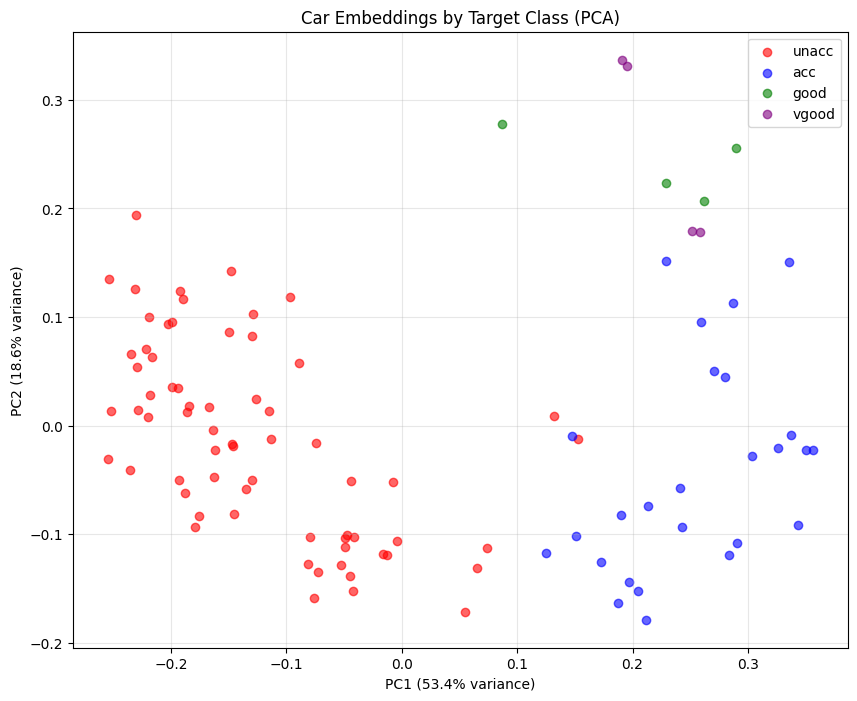

In [21]:
# Visualize embeddings with PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get embeddings for more samples
viz_samples = eval_data[:100]
viz_embeddings = pipeline.embed_batch(viz_samples)  # Already numpy array
viz_targets = [s["target"] for s in viz_samples]

# Reduce to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(viz_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"unacc": "red", "acc": "blue", "good": "green", "vgood": "purple"}
for target in colors:
    mask = [t == target for t in viz_targets]
    points = embeddings_2d[mask]
    if len(points) > 0:
        ax.scatter(points[:, 0], points[:, 1], c=colors[target], label=target, alpha=0.6)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Car Embeddings by Target Class (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 9. Summary

This notebook demonstrated the key features of `OrigamiPipeline`:

### Configuration
```python
# Default config
pipeline = OrigamiPipeline()

# Custom config
config = PipelineConfig(
    d_model=128, n_layers=4, batch_size=32, ...
)
pipeline = OrigamiPipeline(config)
```

### Training
```python
pipeline.fit(train_data, eval_data=eval_data, epochs=10)
```

### Save/Load
```python
pipeline.save("model.pt")
pipeline = OrigamiPipeline.load("model.pt")
```

### Prediction
```python
# Single prediction (returns the value directly)
result = pipeline.predict(obj, target_key="field")

# Get probability distribution
probs = pipeline.predict_proba(obj, target_key="field")  # Returns dict

# Get top-k predictions with probabilities
top_k = pipeline.predict_proba(obj, target_key="field", top_k=5)  # Returns list of tuples

# Batch prediction (returns list of values)
results = pipeline.predict_batch(objects, target_key="field")
```

### Generation
```python
samples = pipeline.generate(num_samples=10, temperature=1.0, seed=42)
```

### Embeddings
```python
# Single embedding
emb = pipeline.embed(obj, pooling="mean")

# Batch embeddings
embs = pipeline.embed_batch(objects)
```

### Key Parameters
| Parameter | Description | Default |
|-----------|-------------|---------|
| `d_model` | Embedding dimension | 256 |
| `n_layers` | Transformer layers | 6 |
| `n_heads` | Attention heads | 8 |
| `numeric_mode` | "none", "discretize", "scale" | "none" |
| `shuffle_keys` | Key order augmentation | True |
| `upscale_factor` | Augmentation multiplier | 1 |